# Configuration type classification

Predicts the configuration type of a binary Bar–Y superlattice — **Bar-dominant**, **balanced**, **Y-dominant** or **expanded** — from the two branch lengths $\mathbf{x} = [L_{0,\mathrm{Bar}},\, L_{0,\mathrm{Y}}]$.

* **Data**: 176 simulated designs (sheet `configuration type` of `data/Supplementary Data 4.xlsx`).
* **Model selection**: GPC, *k*-NN classifier, SVM, RF, tested over 20 random 80/20 training/testing splits. The hyperparameters of the *k*-NN, SVM and RF classifiers are chosen by a five-fold grid search inside the training data of every split. Those of the GPC are optimized by marginal-likelihood maximization.
* **Deployment**: the GPC fitted on all 176 designs is saved to `models/gpc_classifier.joblib` and used by `pareto_optimization.ipynb` to exclude expanded designs from the property surrogate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed, dump, load

from sklearn.ensemble import RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

import mega_utils as mu

mu.apply_plot_style()

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)   # kernel amplitude near its bound is expected here

N_JOBS = 8 # parallel
RETRAIN = False        # False: load the saved results and models and only draw the tables and figures; True: retrain everything

data = mu.load_classification()
X = data[["L0Bar", "L0Y"]].to_numpy()
y = data["Class"].to_numpy(dtype=int)
counts = {mu.CLASS_NAMES[k]: int(v) for k, v in data.Class.value_counts().sort_index().items()}
print(f"{len(data)} designs: {counts}")

176 designs: {'Bar-dominant': 51, 'Balanced': 35, 'Y-dominant': 32, 'Expanded': 58}


## 1. Dataset

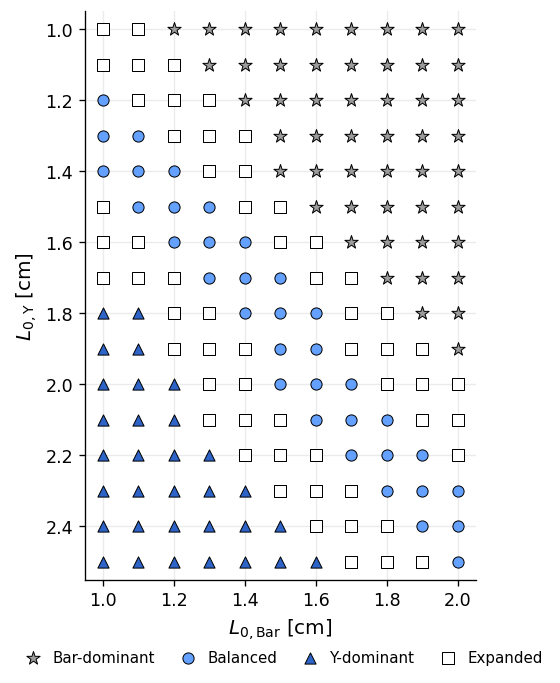

In [2]:
CLASS_COLORS = {1: "#9C9C9C", 2: "#64A1FF", 3: "#2E64C8", 4: "white"}
CLASS_MARKERS = {1: "*", 2: "o", 3: "^", 4: "s"}

fig, ax = plt.subplots(figsize=(5.0, 5.8))
for k, name in mu.CLASS_NAMES.items():
    d = data[data.Class == k]
    ax.scatter(d.L0Bar, d.L0Y, marker=CLASS_MARKERS[k], s=70 if k == 1 else 45,
               c=CLASS_COLORS[k], edgecolors="k", linewidths=0.6, label=name, zorder=3)
ax.set_xlabel("$L_{0,\\mathrm{Bar}}$ [cm]"); ax.set_ylabel("$L_{0,\\mathrm{Y}}$ [cm]")
ax.set_xlim(0.95, 2.05); ax.set_ylim(2.55, 0.95)
ax.set_aspect("equal"); ax.grid(color="0.92", zorder=0)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=9, handletextpad=0.3, columnspacing=1.2)
plt.tight_layout()
plt.show()

## 2. Candidate classifiers

| model | tuned hyperparameters |
|---|---|
| GPC | kernel hyperparameters by marginal-likelihood maximisation (5 restarts) |
| *k*-NN | $k \in \{1, 3, 5, 7\}$ |
| SVM (RBF) | $C \in \{1, 10, 100\}$, $\gamma \in \{\text{scale}, 1, 10\}$ (inputs standardised) |
| random forest | maximum depth $\in \{\text{none}, 4, 8\}$, 400 trees |

In [3]:
def tuned(estimator, grid):
    def factory(y_train):
        n_inner = min(5, int(np.bincount(y_train)[np.nonzero(np.bincount(y_train))].min()))
        cv = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=0)
        return GridSearchCV(estimator, grid, cv=cv, n_jobs=1)
    return factory


def make_methods():
    return {
        "GPC": lambda y_train: GaussianProcessClassifier(
            kernel=ConstantKernel(1.0, (1e-5, 1e5)) * RBF(length_scale=1.0, length_scale_bounds=(1e-3, 1e5)),
            n_restarts_optimizer=5, random_state=42),
        "k-NN": tuned(KNeighborsClassifier(), {"n_neighbors": [1, 3, 5, 7]}),
        "SVM": tuned(make_pipeline(StandardScaler(), SVC(random_state=42)),
                     {"svc__C": [1.0, 10.0, 100.0], "svc__gamma": ["scale", 1.0, 10.0]}),
        "RF": tuned(RandomForestClassifier(n_estimators=400, random_state=42), {"max_depth": [None, 4, 8]}),
    }


METHODS = list(make_methods())
print(METHODS)

['GPC', 'k-NN', 'SVM', 'RF']


## 3. Evaluation over 20 random 80/20 splits

Each classifier is trained on the 80 % part and scored on the held-out 20 % of every split. The table reports the mean ± standard deviation of the testing accuracy over the 20 splits (Supplementary Table 2).

In [4]:
splits = mu.repeated_random(len(data), n_repeats=20, test_size=0.2)


def run_split(sp):
    rows = []
    for name, factory in make_methods().items():
        model = factory(y[sp.train]).fit(X[sp.train], y[sp.train])
        pred = model.predict(X[sp.test])
        rows.append({"model": name, "split": sp.fold, "n_train": len(sp.train), "n_test": len(sp.test),
                     "accuracy": float((pred == y[sp.test]).mean())})
    return rows


if RETRAIN:
    out = Parallel(n_jobs=N_JOBS)(delayed(run_split)(sp) for sp in splits)
    per_split = pd.DataFrame([r for rows in out for r in rows])
    mu.save_results(per_split, "classification_accuracy_per_split.csv")
else:
    per_split = mu.load_results("classification_accuracy_per_split.csv")

summary = (per_split.groupby("model").accuracy.agg(["mean", "std", "min", "max"])
           .loc[METHODS].reset_index())
if RETRAIN:
    mu.save_results(summary, "classification_accuracy_summary.csv")

table = pd.DataFrame({"Classification accuracy": [f"{m:.3f} ± {s:.3f}" for m, s in zip(summary["mean"], summary["std"])]},
                     index=summary.model).T
table

model,GPC,k-NN,SVM,RF
Classification accuracy,0.942 ± 0.037,0.843 ± 0.061,0.958 ± 0.032,0.749 ± 0.055


## 4. Final classifier

The GPC is fitted on all 176 designs and saved. 

fitted kernels (one-vs-rest):
   Bar-dominant  316**2 * RBF(length_scale=1.48)
   Balanced      316**2 * RBF(length_scale=0.71)
   Y-dominant    36.3**2 * RBF(length_scale=0.661)
   Expanded      19.6**2 * RBF(length_scale=0.175)


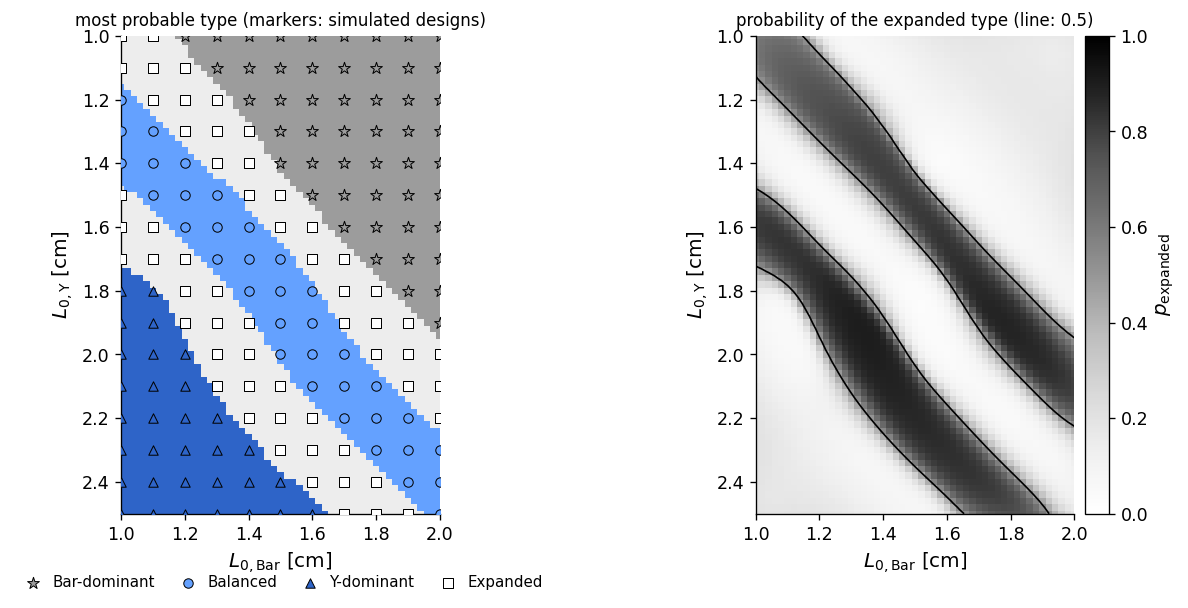

65.7 % of the design box is classified as contracted


In [5]:
path = f"{mu.MODELS_DIR}/gpc_classifier.joblib"
if RETRAIN:
    gpc = make_methods()["GPC"](y).fit(X, y)
    dump(gpc, path)
else:
    gpc = load(path)
print("fitted kernels (one-vs-rest):")
for k, e in zip(gpc.classes_, gpc.base_estimator_.estimators_):
    print(f"   {mu.CLASS_NAMES[k]:13s} {e.kernel_}")

GB, GY, Xgrid = mu.design_grid(step=0.02)
proba = gpc.predict_proba(Xgrid)
type_grid = gpc.classes_[proba.argmax(axis=1)].reshape(GB.shape)
p_expanded = proba[:, list(gpc.classes_).index(mu.INFEASIBLE_CLASS)].reshape(GB.shape)

from matplotlib.colors import ListedColormap
fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.2))
ax = axes[0]
cmap = ListedColormap([CLASS_COLORS[1], CLASS_COLORS[2], CLASS_COLORS[3], "#EDEDED"])
ax.pcolormesh(GB, GY, type_grid, cmap=cmap, vmin=0.5, vmax=4.5, shading="nearest", rasterized=True)
for k, name in mu.CLASS_NAMES.items():
    d = data[data.Class == k]
    ax.scatter(d.L0Bar, d.L0Y, marker=CLASS_MARKERS[k], s=55 if k == 1 else 32, c=CLASS_COLORS[k],
               edgecolors="k", linewidths=0.6, label=name, zorder=3)
ax.set_title("most probable type (markers: simulated designs)", fontsize=10)
ax.legend(frameon=False, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, handletextpad=0.3, columnspacing=1.2)
ax = axes[1]
m = ax.pcolormesh(GB, GY, p_expanded, cmap="Greys", vmin=0, vmax=1, shading="nearest", rasterized=True)
ax.contour(GB, GY, p_expanded, levels=[0.5], colors="k", linewidths=1.0)
plt.colorbar(m, ax=ax, pad=0.02).set_label("$p_{\\mathrm{expanded}}$")
ax.set_title("probability of the expanded type (line: 0.5)", fontsize=10)
for ax in axes:
    ax.set_xlabel("$L_{0,\\mathrm{Bar}}$ [cm]"); ax.set_ylabel("$L_{0,\\mathrm{Y}}$ [cm]")
    ax.set_xlim(mu.L_BAR_BOUNDS); ax.set_ylim(mu.L_Y_BOUNDS[1], mu.L_Y_BOUNDS[0]); ax.set_aspect("equal")
plt.tight_layout()
plt.show()

feasible = (type_grid != mu.INFEASIBLE_CLASS).mean()
print(f"{feasible * 100:.1f} % of the design box is classified as contracted")

## Outputs

* `results/classification_accuracy_per_split.csv`, `results/classification_accuracy_summary.csv` — accuracy of every candidate over the 20 splits (Supplementary Table 2).
* `models/gpc_classifier.joblib` — the GPC fitted on all 176 designs, loaded by `pareto_optimization.ipynb`.